# Intensity window sampling

Sample contiguous 4-week carbon and water intensity windows per zone (PL, FR, DE) for the environmental-aware scheduling experiments. The 4-week workload extracts (see `../workloads and platforms/mustang.ipynb`) are replayed against every sampled window, and the evaluation metrics are reported as distributions over windows, not single numbers. The aim is therefore even, unbiased coverage of 2018-2025, not hand-picked extreme regimes.

Windows are anchored at Monday 00:00 local time, matching the Monday-anchored workload extracts, and stratified by the meteorological season of their start date (DJF winter, MAM spring, JJA summer, SON autumn).

Each extract is `EXTRACT_DAYS` (35) days long: the 28-day scheduling window plus a 7-day tail. The tail ensures the intensity trace outlasts simulations whose jobs spill past the 4-week mark due to queuing delays. Window descriptors are computed on the 28-day portion only.

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
K = 3  # sampled windows per season per zone
SEED = 20180101  # fixed RNG seed, makes the sampling reproducible

STEP_SEC = 900
STEPS_PER_DAY = 24 * 3600 // STEP_SEC
WINDOW_DAYS = 28
WINDOW_STEPS = WINDOW_DAYS * STEPS_PER_DAY  # 2688

TAIL_DAYS = 7
EXTRACT_DAYS = WINDOW_DAYS + TAIL_DAYS
EXTRACT_STEPS = EXTRACT_DAYS * STEPS_PER_DAY

ZONE_ID = "AS0"  # zone name used inside the traces
ZONES = {"DE": "Europe/Berlin", "FR": "Europe/Paris", "PL": "Europe/Warsaw"}
TRACE_START = "2018-01-01"  # Monday 00:00 local time, timestamp 0 in every trace

SEASON_OF_MONTH = {12: "winter", 1: "winter", 2: "winter",
                   3: "spring", 4: "spring", 5: "spring",
                   6: "summer", 7: "summer", 8: "summer",
                   9: "autumn", 10: "autumn", 11: "autumn"}
SEASON_ORDER = ["winter", "spring", "summer", "autumn"]

## Loading the traces

`traces/<CC>.csv` is the long format Batsim consumes: `timestamp,zone,property,value` with two properties per instant (`carbon_intensity` in gCO2eq/kWh, `water_intensity` in L/kWh). Timestamps are seconds elapsed since 2018-01-01 00:00 local time, stepping by 900. Pivot to one row per instant and check the grid is gapless.

In [3]:
traces = {}
for cc in ZONES:
    long = pd.read_csv(f"traces/{cc}.csv")
    wide = long.pivot(index="timestamp", columns="property", values="value")
    assert list(wide.columns) == ["carbon_intensity", "water_intensity"]
    assert wide.index[0] == 0 and (np.diff(wide.index) == STEP_SEC).all()
    assert not wide.isna().any().any()
    traces[cc] = wide
    print(f"{cc}: {len(wide)} instants, {(wide.index[-1] + STEP_SEC) / 86400:g} days")
n_steps = len(traces["DE"])

DE: 280512 instants, 2922 days
FR: 280512 instants, 2922 days


PL: 280512 instants, 2922 days


## Candidate windows

Candidates are every Monday 00:00 local time whose window fits in the trace. Because the trace timestamps are elapsed seconds, a local Monday 00:00 maps to the tz-aware difference from the trace origin: always a multiple of 900, but not always of 86400, since DST transitions shift the wall clock. A window is a fixed count of 2688 consecutive 15-minute steps (28 days x 96), not a fixed local-calendar span, so a DST transition inside a window never changes the row count. This matches the elapsed-time semantics of the Batsim replay.

Descriptors per candidate window, computed on `carbon_intensity` with `water_intensity` reported alongside:

- `mean_carbon`, `mean_water`: window mean levels.
- `swing_carbon`, `swing_water`: mean daily peak-to-trough range over the 28 elapsed-time days, divided by the window mean. A dimensionless intra-day variability measure.

These are descriptors for the later analysis (correlating heuristic gains with signal variability), not selection filters.

In [4]:
def window_descriptors(wide, start_step):
    win = wide.iloc[start_step : start_step + WINDOW_STEPS]
    carbon = win["carbon_intensity"].to_numpy().reshape(WINDOW_DAYS, STEPS_PER_DAY)
    water = win["water_intensity"].to_numpy().reshape(WINDOW_DAYS, STEPS_PER_DAY)
    mean_carbon, mean_water = carbon.mean(), water.mean()
    return {
        "mean_carbon": mean_carbon,
        "mean_water": mean_water,
        "swing_carbon": (carbon.max(axis=1) - carbon.min(axis=1)).mean() / mean_carbon,
        "swing_water": (water.max(axis=1) - water.min(axis=1)).mean() / mean_water,
    }


candidates = {}
for cc, tz in ZONES.items():
    origin = pd.Timestamp(TRACE_START, tz=tz)
    rows = []
    for monday in pd.date_range(TRACE_START, periods=n_steps // (7 * STEPS_PER_DAY) + 1, freq="W-MON"):
        elapsed = (monday.tz_localize(tz) - origin).total_seconds()
        assert elapsed % STEP_SEC == 0
        start_step = int(elapsed) // STEP_SEC
        if start_step + WINDOW_STEPS > n_steps:
            break
        rows.append({
            "start_date": monday.date(),
            "start_step": start_step,
            "season": SEASON_OF_MONTH[monday.month],
            "year": monday.year,
            **window_descriptors(traces[cc], start_step),
        })
    candidates[cc] = pd.DataFrame(rows)

cand_de = candidates["DE"]
print(f"{len(cand_de)} candidate windows per zone, "
      f"{cand_de['start_date'].iloc[0]} to {cand_de['start_date'].iloc[-1]}")
cand_de.groupby("season")[["start_date", "year"]].agg(windows=("start_date", "size"), years=("year", "nunique"))

414 candidate windows per zone, 2018-01-01 to 2025-12-01


,windows,years
season,,
autumn,104,8
spring,105,8
summer,105,8
winter,100,8


## Sampling rule

K = 3 windows per season per zone. All draws come from a single `np.random.default_rng(SEED)` consumed in a fixed order (zones sorted alphabetically, seasons in winter, spring, summer, autumn order), so the sample is fully reproducible. For each (zone, season):

1. Draw K distinct years uniformly without replacement from the years that have candidates in that season. Every season has candidates in all 8 years, so the sampled years are always distinct.
2. Within each drawn year, draw one candidate Monday uniformly.

The draws are pure random sampling with no descriptor-based filtering, to keep the sample unbiased. Sampling is independent per zone, so the 36 windows cover more distinct calendar periods than reusing the same dates in every zone.

In [5]:
rng = np.random.default_rng(SEED)
sampled = {}
for cc in sorted(ZONES):
    picks = []
    for season in SEASON_ORDER:
        pool = candidates[cc][candidates[cc]["season"] == season]
        years = np.sort(pool["year"].unique())
        for year in rng.choice(years, size=min(K, len(years)), replace=False):
            in_year = pool[pool["year"] == year]
            picks.append(in_year.iloc[rng.integers(len(in_year))])
    sampled[cc] = pd.DataFrame(picks).sort_values("start_step").reset_index(drop=True)

pd.concat(sampled, names=["zone"]).drop(columns="start_step").round(3)

start_date  season  year  mean_carbon  mean_water  swing_carbon  \
zone                                                                       
DE   0   2019-02-04  winter  2019      353.041       1.518         0.319   
     1   2019-07-01  summer  2019      329.507       1.795         0.516   
     2   2019-11-25  autumn  2019      310.172       1.422         0.385   
     3   2021-04-05  spring  2021      310.879       1.446         0.511   
     4   2021-06-07  summer  2021      354.311       1.915         0.517   
     5   2021-10-25  autumn  2021      357.949       1.454         0.290   
     6   2021-12-13  winter  2021      339.457       1.407         0.317   
     7   2023-01-16  winter  2023      403.333       1.468         0.301   
     8   2023-05-29  spring  2023      291.352       1.614         0.833   
     9   2023-08-14  summer  2023      375.601       1.779         0.765   
     10  2023-11-27  autumn  2023      356.064       1.430         0.292   
     11  2025-03-24  spring  2025      315.889       1.274         0.931   
FR   0   2018-03-12  spring  2018       44.046       3.690         0.292   
     1   2019-09-23  autumn  2019       33.403       2.634         0.408   
     2   2020-01-27  winter  2020       38.630       3.328         0.306   
     3   2021-01-18  winter  2021       45.525       3.829         0.266   
     4   2021-03-29  spring  2021       38.722       3.149         0.279   
     5   2021-07-26  summer  2021       24.566       3.434         0.274   
     6   2021-09-13  autumn  2021       33.571       3.002         0.514   
     7   2022-08-01  summer  2022       44.721       2.821         0.274   
     8   2022-09-26  autumn  2022       47.397       2.844         0.316   
     9   2024-03-04  spring  2024       33.986       3.790         0.319   
     10  2024-06-03  summer  2024       24.037       3.947         0.181   
     11  2024-12-16  winter  2024       28.316       3.309         0.381   
PL   0   2018-06-18  summer  2018      676.407       1.728         0.085   
     1   2019-07-01  summer  2019      642.382       1.686         0.124   
     2   2019-10-14  autumn  2019      625.627       1.672         0.147   
     3   2020-02-24  winter  2020      574.196       1.713         0.181   
     4   2020-07-20  summer  2020      631.778       1.730         0.144   
     5   2021-05-03  spring  2021      578.968       1.695         0.221   
     6   2021-12-13  winter  2021      594.537       1.603         0.170   
     7   2022-09-05  autumn  2022      609.671       1.578         0.246   
     8   2022-12-26  winter  2022      508.333       1.497         0.243   
     9   2023-05-01  spring  2023      501.265       1.511         0.497   
     10  2023-10-23  autumn  2023      526.832       1.510         0.240   
     11  2024-05-20  spring  2024      522.534       1.437         0.608   

         swing_water  
zone                  
DE   0         0.316  
     1         0.522  
     2         0.294  
     3         0.457  
     4         0.561  
     5         0.291  
     6         0.270  
     7         0.301  
     8         0.803  
     9         0.709  
     10        0.274  
     11        0.841  
FR   0         0.189  
     1         0.266  
     2         0.257  
     3         0.186  
     4         0.343  
     5         0.262  
     6         0.322  
     7         0.435  
     8         0.350  
     9         0.308  
     10        0.268  
     11        0.277  
PL   0         0.096  
     1         0.112  
     2         0.136  
     3         0.166  
     4         0.122  
     5         0.212  
     6         0.148  
     7         0.273  
     8         0.216  
     9         0.463  
     10        0.250  
     11        0.597

## Extracts and manifest

One extract per sampled window: `traces/<CC>_<YYYY-MM-DD>.csv`, the same long format as the full traces, timestamps rebased to start at 0. Each extract covers `EXTRACT_DAYS` (35) days: the 28-day scheduling window plus a 7-day tail. The tail ensures the intensity trace outlasts any simulation whose jobs spill past the 4-week mark due to queuing delays. Descriptors in the manifest are still computed on the 28-day window only.

Stale extracts from previous runs are removed first so the directory always mirrors the current sample. `windows.csv` is the manifest the experiment runner iterates over, with the file paths relative to this directory.

In [6]:
def window_extract(wide, start_step):
    win = wide.iloc[start_step : start_step + EXTRACT_STEPS]
    return pd.DataFrame({
        "timestamp": (np.arange(EXTRACT_STEPS) * STEP_SEC).repeat(2),
        "zone": ZONE_ID,
        "property": ["carbon_intensity", "water_intensity"] * EXTRACT_STEPS,
        "value": np.column_stack([win["carbon_intensity"], win["water_intensity"]]).ravel(),
    })


for stale in glob.glob("traces/??_????-??-??.csv"):
    os.remove(stale)

manifest = []
for cc in sorted(ZONES):
    for row in sampled[cc].itertuples():
        assert row.start_step + EXTRACT_STEPS <= len(traces[cc]), \
            f"{cc}_{row.start_date}: not enough trace data for {EXTRACT_DAYS}-day extract"
        file = f"traces/{cc}_{row.start_date}.csv"
        window_extract(traces[cc], row.start_step).to_csv(file, index=False)
        manifest.append({
            "zone": cc, "file": file, "start_date": row.start_date,
            "season": row.season, "year": row.year,
            "mean_carbon": round(row.mean_carbon, 4),
            "mean_water": round(row.mean_water, 4),
            "swing_carbon": round(row.swing_carbon, 4),
            "swing_water": round(row.swing_water, 4),
        })
manifest = pd.DataFrame(manifest)
manifest.to_csv("windows.csv", index=False)
print(f"wrote {len(manifest)} extracts ({EXTRACT_DAYS}-day windows) and windows.csv")

wrote 36 extracts (35-day windows) and windows.csv


## Coverage of the candidate space

Mean level and swing of every candidate window over 2018-2025, with the sampled windows marked. The histograms compare the carbon and water swing of the sampled windows against all candidates, to show the sample is representative of the population rather than skewed toward extreme regimes.

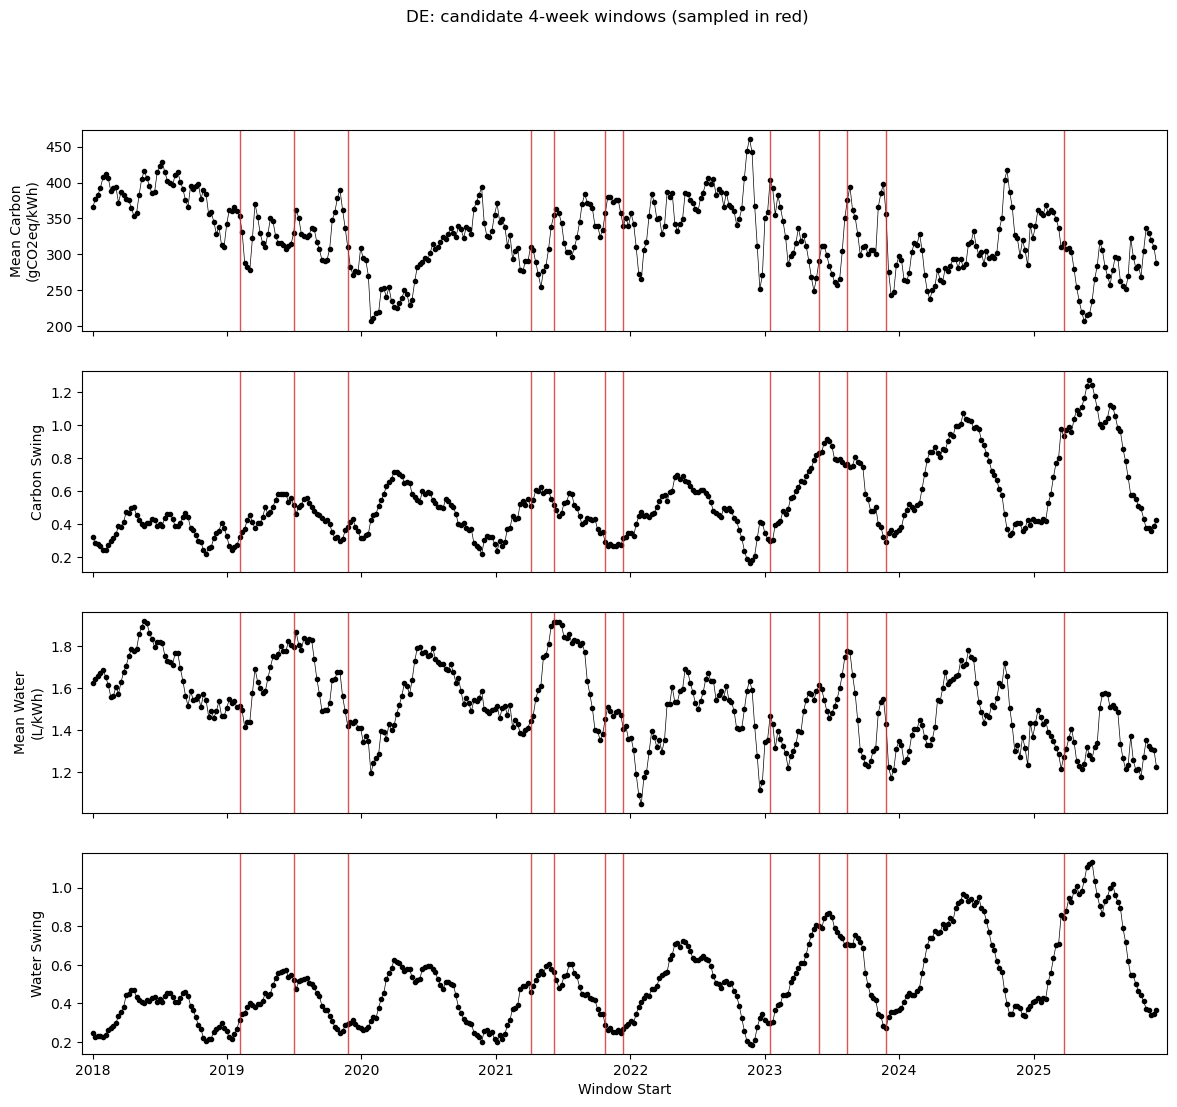

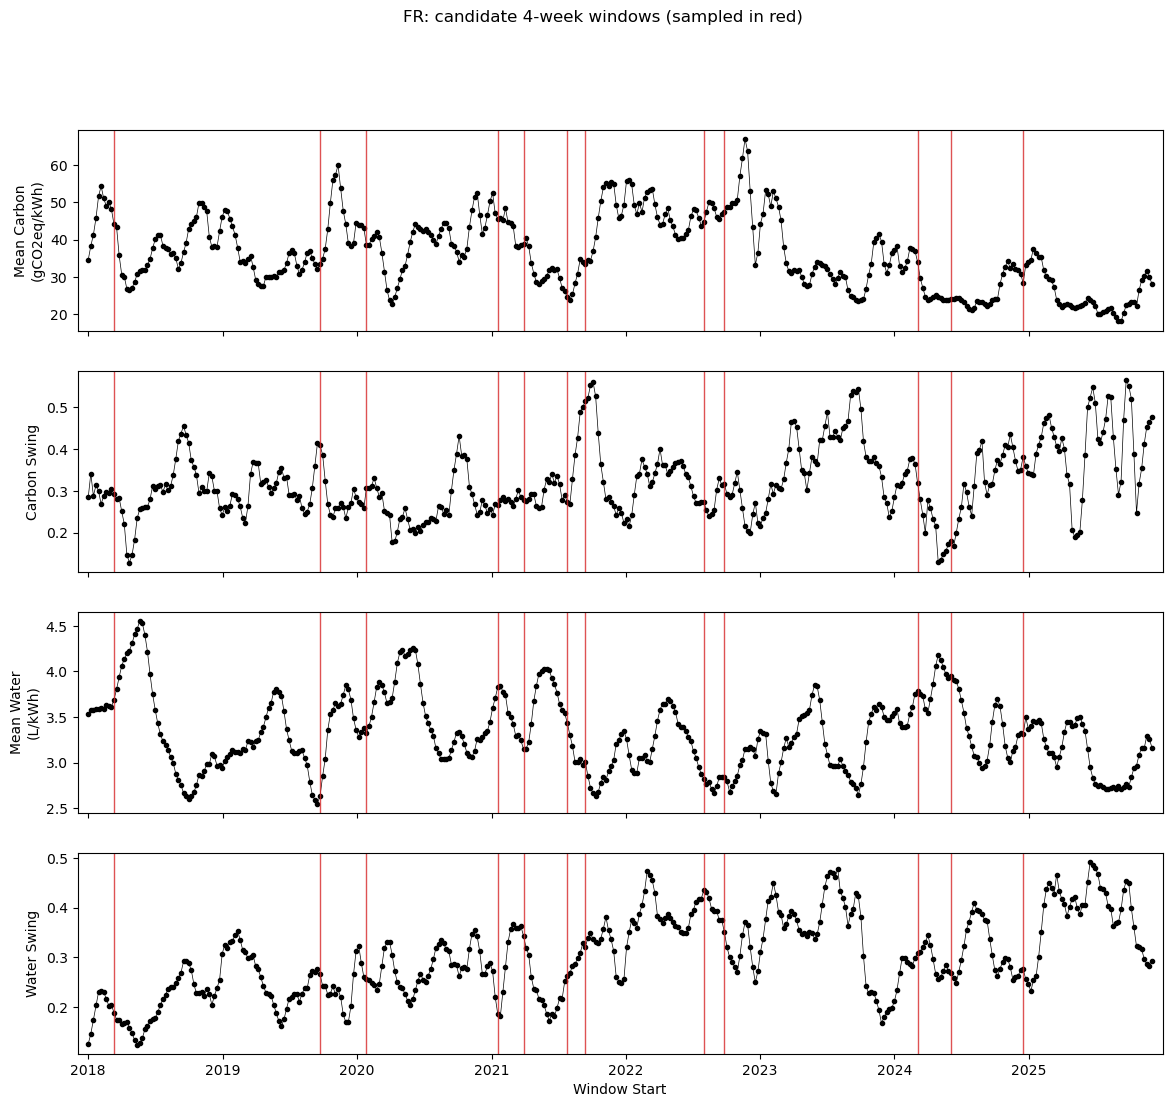

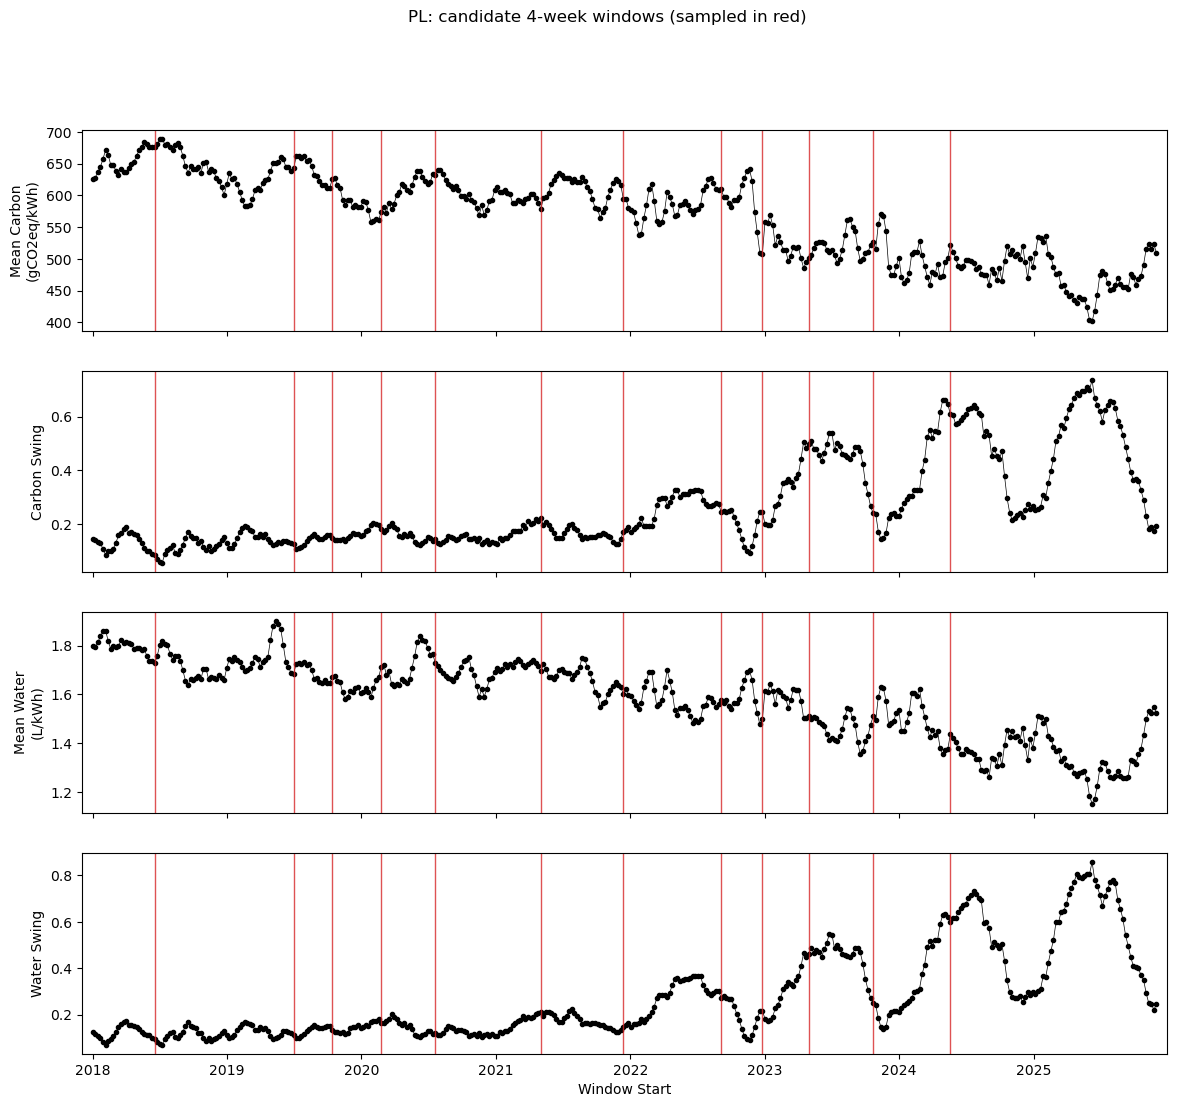

In [7]:
for cc in sorted(ZONES):
    cand, samp = candidates[cc], sampled[cc]
    x = pd.to_datetime(cand["start_date"])
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    panels = [("mean_carbon", "Mean Carbon\n(gCO2eq/kWh)"), ("swing_carbon", "Carbon Swing"),
              ("mean_water", "Mean Water\n(L/kWh)"), ("swing_water", "Water Swing")]
    for ax, (metric, label) in zip(axes, panels):
        ax.plot(x, cand[metric], marker=".", color="black", linewidth=0.5)
        ax.set_ylabel(label)
    axes[-1].set_xlabel("Window Start")

    for ax in axes:
        for start in pd.to_datetime(samp["start_date"]):
            ax.axvline(start, color="tab:red", linewidth=1, alpha=0.8)
        ax.margins(x=0.01)
    fig.suptitle(f"{cc}: candidate 4-week windows (sampled in red)")
    plt.show()

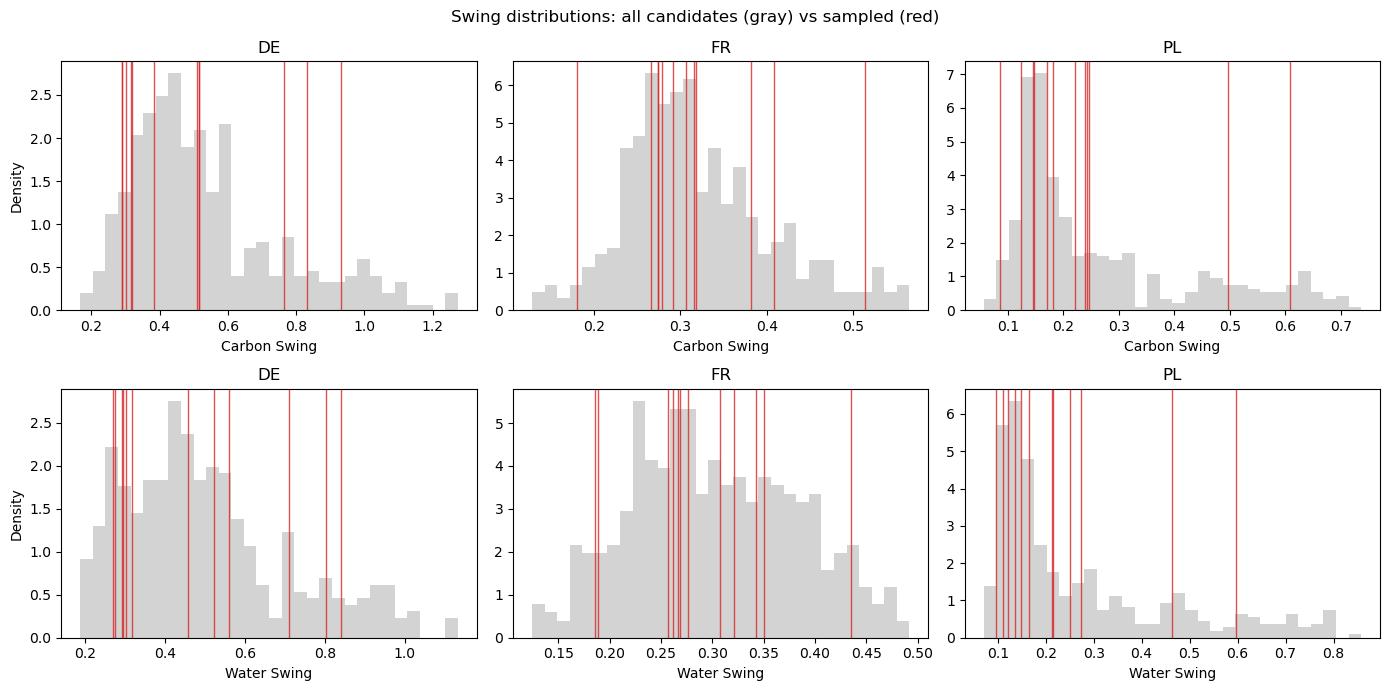

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for row, (metric, label) in enumerate([("swing_carbon", "Carbon Swing"), ("swing_water", "Water Swing")]):
    for ax, cc in zip(axes[row], sorted(ZONES)):
        ax.hist(candidates[cc][metric], bins=30, color="lightgray", density=True)
        for swing in sampled[cc][metric]:
            ax.axvline(swing, color="tab:red", linewidth=1, alpha=0.8)
        ax.set_title(cc)
        ax.set_xlabel(label)
    axes[row][0].set_ylabel("Density")
fig.suptitle("Swing distributions: all candidates (gray) vs sampled (red)")
fig.tight_layout()
plt.show()

## Validation

Re-read everything from disk and check: the manifest has K windows per season per zone from distinct years, every extract has exactly 2688 timestamps x 2 properties stepping 900 from 0 with no missing values, the extract values match the source trace slice, and the stored descriptors recompute from the source.

In [9]:
check = pd.read_csv("windows.csv")
assert len(check) == len(ZONES) * len(SEASON_ORDER) * K
per_stratum = check.groupby(["zone", "season"]).agg(n=("file", "size"), years=("year", "nunique"))
assert (per_stratum["n"] == K).all() and (per_stratum["years"] == K).all()
assert sorted(check["file"]) == sorted(glob.glob("traces/??_????-??-??.csv"))

expected_ts = np.arange(EXTRACT_STEPS) * STEP_SEC
for row in check.itertuples():
    extract = pd.read_csv(row.file)
    assert len(extract) == EXTRACT_STEPS * 2, row.file
    assert not extract.isna().any().any(), row.file
    assert (extract["zone"] == ZONE_ID).all(), row.file
    for prop in ["carbon_intensity", "water_intensity"]:
        ts = extract.loc[extract["property"] == prop, "timestamp"]
        assert (ts.to_numpy() == expected_ts).all(), (row.file, prop)

    tz = ZONES[row.zone]
    elapsed = (pd.Timestamp(row.start_date, tz=tz) - pd.Timestamp(TRACE_START, tz=tz)).total_seconds()
    start_step = int(elapsed) // STEP_SEC
    source = traces[row.zone].iloc[start_step : start_step + EXTRACT_STEPS]
    wide = extract.pivot(index="timestamp", columns="property", values="value")
    assert np.array_equal(wide.to_numpy(), source.to_numpy()), row.file

    desc = window_descriptors(traces[row.zone], start_step)
    for key in ["mean_carbon", "mean_water", "swing_carbon", "swing_water"]:
        assert np.isclose(getattr(row, key), desc[key], atol=5e-5), (row.file, key)

print(f"validated {len(check)} extracts: stratification, row counts, timestamp grid, values, descriptors")

validated 36 extracts: stratification, row counts, timestamp grid, values, descriptors
